In [365]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [366]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import math
from scipy import stats

In [367]:
# Set display to show all columns
pd.set_option('display.max_columns', None)
sns.set_context("talk")

# Download dataset

In [368]:
kaggle_dataset_name = "marixe/zara-sales-for-eda"

# import sys
# import os

# # Get current notebook directory
# notebook_dir = os.getcwd()
# # Get parent directory (where both 'src' and notebook folder live)
# parent_dir = os.path.dirname(notebook_dir)
# # Add parent to path
# sys.path.append(parent_dir)
# print(f'notebook folder path: {notebook_dir}')
# print(f'parent folder path of both src & notebook: {parent_dir}')
# from src.extractor.extract_function import extract_data_from_kaggle
# file_path = extract_data_from_kaggle(kaggle_dataset_name)
# print(file_path)

# Import dataset

In [452]:
file_path = r'C:\\Users\\haiduong.nguyenle\\.cache\\kagglehub\\datasets\\marixe\\zara-sales-for-eda\\versions\\5\\Zara_sales_EDA.csv'

df = pd.read_csv(file_path, delimiter=';')
print(f'data shape: {df.shape}')
df.head(5)

data shape: (20252, 17)


,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,name,description,price,currency,terms,section,season,material,origin
0,185102,Aisle,Yes,clothing,Yes,1243,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,78.99,USD,jackets,MAN,Winter,Polyester,Brazil
1,188771,Aisle,Yes,clothing,No,1429,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,14.99,USD,jackets,MAN,Autumn,Cotton,Turkey
2,180176,End-cap,Yes,clothing,Yes,1168,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,71.95,USD,jackets,WOMAN,Autumn,Polyester,Morocco
3,112917,Aisle,Yes,clothing,No,1348,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,30.99,USD,jackets,MAN,Spring,Polyester,China
4,192936,End-cap,Yes,clothing,Yes,1602,Zara,https://www.zara.com/us/en/double-faced-jacket...,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,22.99,USD,jackets,WOMAN,Winter,Wool Blend,China


In [370]:
df.info()
num_col = df.select_dtypes(include='number').columns
obj_col = df.select_dtypes(include='object').columns
print(f'numeric cols: {num_col}')
print(f'object cols: {obj_col}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20252 entries, 0 to 20251
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product ID        20252 non-null  int64  
 1   Product Position  20252 non-null  object 
 2   Promotion         20252 non-null  object 
 3   Product Category  20252 non-null  object 
 4   Seasonal          20252 non-null  object 
 5   Sales Volume      20252 non-null  int64  
 6   brand             20252 non-null  object 
 7   url               20252 non-null  object 
 8   name              20251 non-null  object 
 9   description       20250 non-null  object 
 10  price             20252 non-null  float64
 11  currency          20252 non-null  object 
 12  terms             20252 non-null  object 
 13  section           20252 non-null  object 
 14  season            20252 non-null  object 
 15  material          20252 non-null  object 
 16  origin            20252 non-null  object

# Quality check
Duplicates \
Null

In [371]:
# check dup
df.duplicated().any()

np.False_

In [372]:
# check null
df.isnull().sum()

Product ID          0
Product Position    0
Promotion           0
Product Category    0
Seasonal            0
Sales Volume        0
brand               0
url                 0
name                1
description         2
price               0
currency            0
terms               0
section             0
season              0
material            0
origin              0
dtype: int64

In [373]:
# values categories
for i, col in enumerate(obj_col):
    unique_val = df[col].unique()
    print(f'values in {col}: {unique_val}')

values in Product Position: ['Aisle' 'End-cap' 'Front of Store']
values in Promotion: ['Yes' 'No']
values in Product Category: ['clothing']
values in Seasonal: ['Yes' 'No']
values in brand: ['Zara']
values in url: ['https://www.zara.com/us/en/basic-puffer-jacket-p06985450.html'
 'https://www.zara.com/us/en/tuxedo-jacket-p08896675.html'
 'https://www.zara.com/us/en/slim-fit-suit-jacket-p01564520.html'
 'https://www.zara.com/us/en/stretch-suit-jacket-p01564300.html'
 'https://www.zara.com/us/en/double-faced-jacket-p08281477.html'
 'https://www.zara.com/us/en/contrasting-collar-jacket-p06987331.html'
 'https://www.zara.com/us/en/faux-leather-puffer-jacket-p08281420.html'
 'https://www.zara.com/us/en/suit-jacket-in-100-linen-p04307408.html'
 'https://www.zara.com/us/en/100-wool-suit-jacket-p05955218.html'
 'https://www.zara.com/us/en/100-feather-fill-puffer-jacket-p04302305.html'
 'https://www.zara.com/us/en/herringbone-textured-jacket-p08491401.html'
 'https://www.zara.com/us/en/oversized

# Clean

In [374]:
df.columns

Index(['Product ID', 'Product Position', 'Promotion', 'Product Category',
       'Seasonal', 'Sales Volume', 'brand', 'url', 'name', 'description',
       'price', 'currency', 'terms', 'section', 'season', 'material',
       'origin'],
      dtype='object')

In [458]:
df['sales'] = df['Sales Volume'] * df['price']
num_col = ['Sales Volume', 'price', 'sales']
obj_col = ['Product Position', 'Promotion', 'Seasonal', 'terms', 'section', 'season', 'material']
print(f'numeric cols: {num_col}')
print(f'object cols: {obj_col}')

numeric cols: ['Sales Volume', 'price', 'sales']
object cols: ['Product Position', 'Promotion', 'Seasonal', 'terms', 'section', 'season', 'material']


# EDA

## distribution

In [376]:
num_col

['Sales Volume', 'price', 'sales']

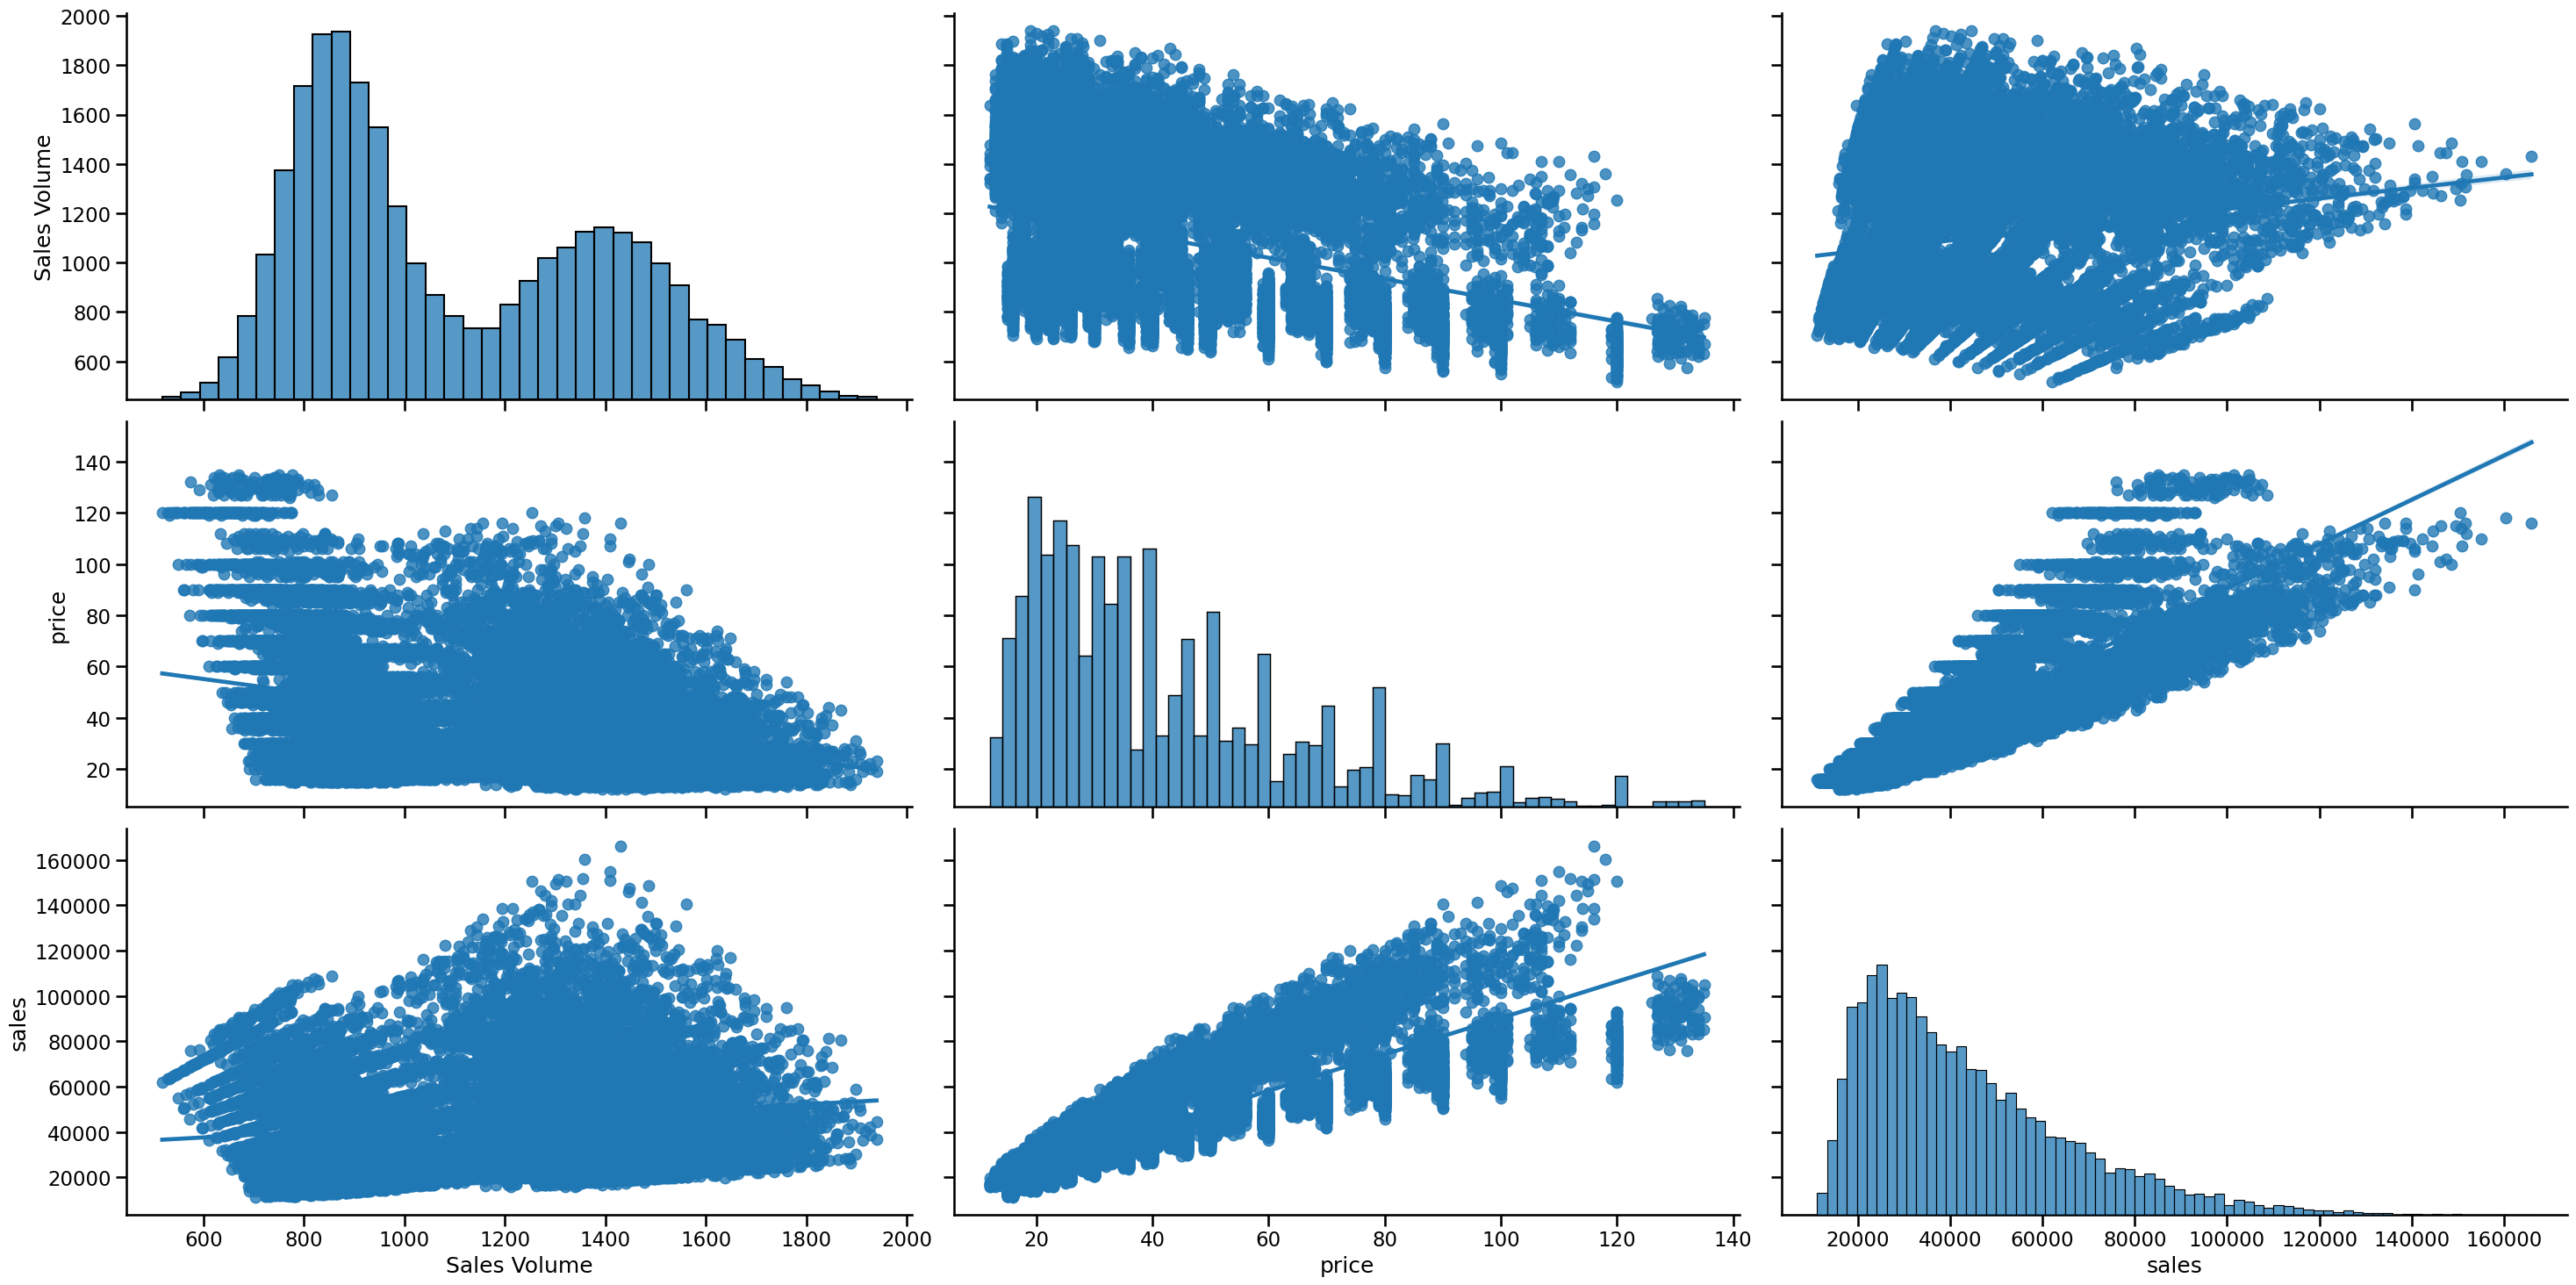

In [377]:
# plt.figure(figsize=(15,8))
ax=sns.pairplot(data=df[['Sales Volume', 'price', 'sales']], kind='reg', height=5, aspect=2, diag_kind='hist' )
# ax.set_titles('distribution of numeric columns')

In [378]:
obj_col

['Product Position',
 'Promotion',
 'Seasonal',
 'terms',
 'section',
 'season',
 'material']

## By product

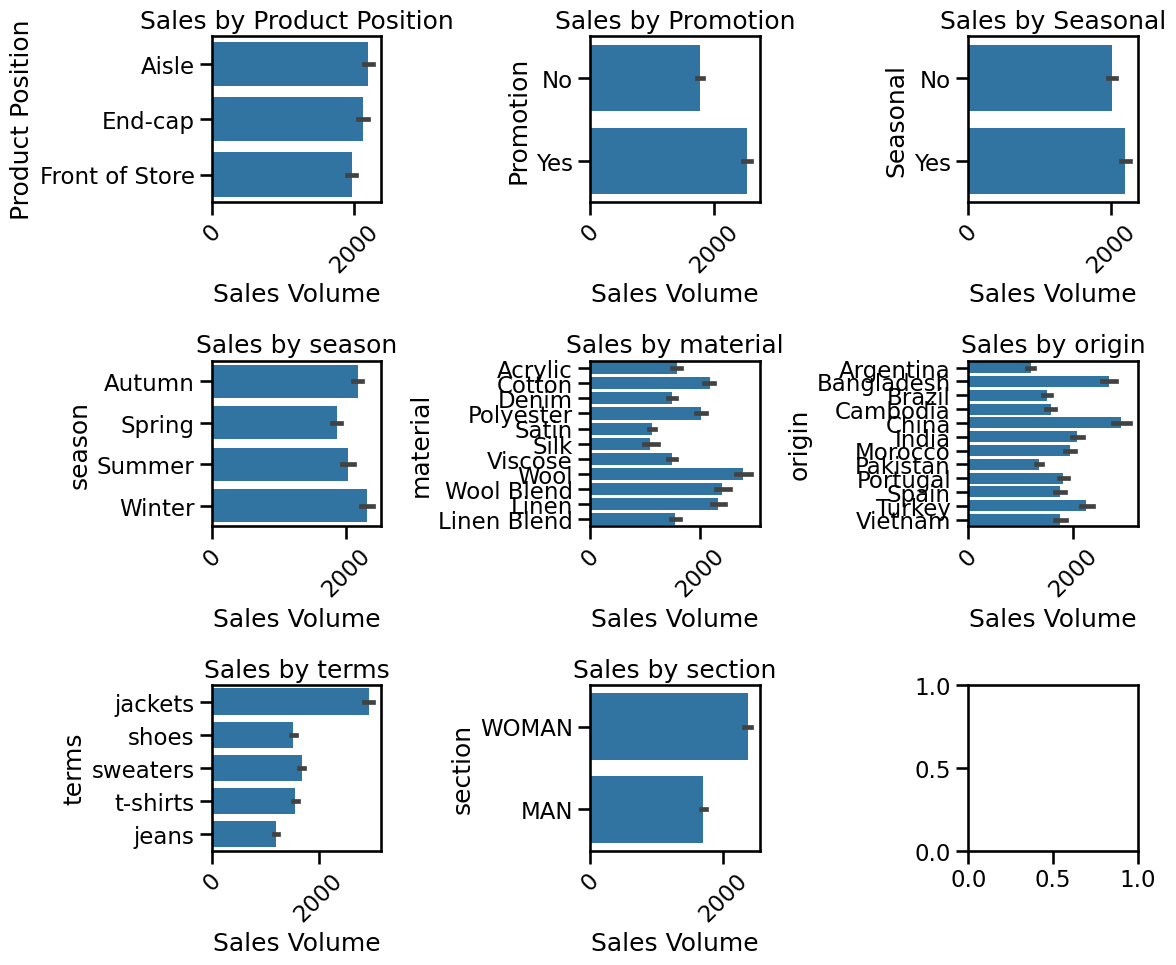

In [379]:
agg_data = df.groupby(by=['Product Position', 'Promotion', 'Seasonal', 'season', 'material', 'origin', 'terms', 'section'])['Sales Volume'].sum().reset_index()
col = ['Product Position', 'Promotion', 'Seasonal', 'season', 'material', 'origin', 'terms', 'section']
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12,10))
axes = axes.flatten()
for i, col in enumerate(col):
    ax = sns.barplot(data=agg_data, y=col, x='Sales Volume', ax=axes[i])
    ax.set_title(f'Sales by {col}')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

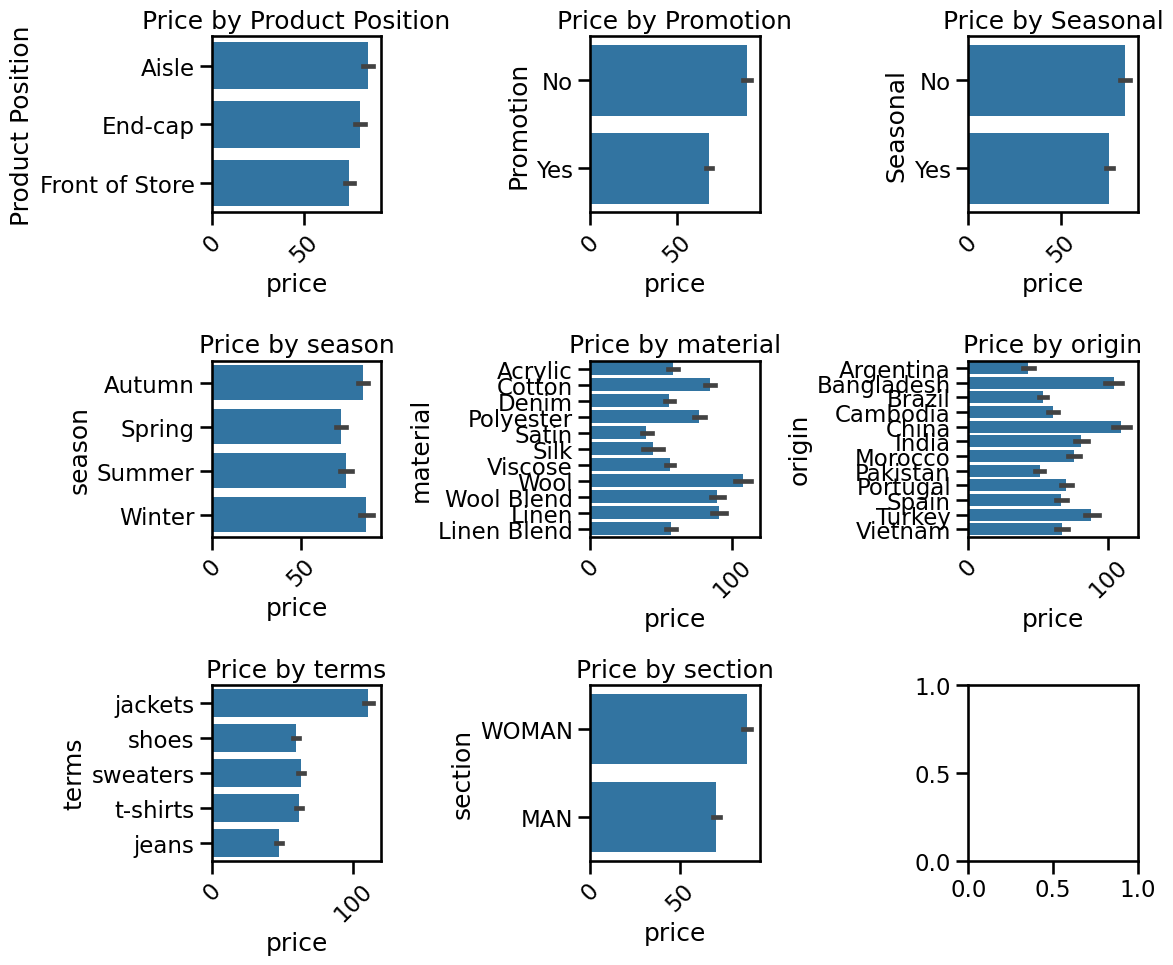

In [380]:
agg_dataprice = df.groupby(by=['Product Position', 'Promotion', 'Seasonal', 'season', 'material', 'origin', 'terms', 'section'])['price'].sum().reset_index()
col = ['Product Position', 'Promotion', 'Seasonal', 'season', 'material', 'origin', 'terms', 'section']
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12,10))
axes = axes.flatten()
for i, col in enumerate(col):
    ax = sns.barplot(data=agg_dataprice, y=col, x='price', ax=axes[i], estimator='mean')
    ax.set_title(f'Price by {col}')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Promotion Lift by Category

# Promotion Uplift


In [381]:
obj_col

['Product Position',
 'Promotion',
 'Seasonal',
 'terms',
 'section',
 'season',
 'material']

In [459]:
# agg_lift = df.pivot_table(index=['Product Position', 'Seasonal', 'terms', 'section', 'season', 'material'], 
#                                       columns = 'Promotion', 
#                                       values=['Sales Volume', 'sales', 'price'], aggfunc='sum').reset_index()
agg_lift = df.pivot_table(
    index=['Product Position', 'terms', 'section', 'season', 'material'], 
    columns='Promotion', 
    values=['Sales Volume', 'sales', 'price'], 
    aggfunc={'Sales Volume': 'sum', 'sales': 'sum', 'price': 'sum', 'Promotion': 'count'}
).reset_index()
agg_lift.columns = ['Product Position', 'terms', 'section', 'season', 'material', 'promotion_no', 'promo_count',
                          'volume_no', 'volume_yes','price_no', 'price_yes', 'sales_no', 'sales_yes'
                          ]

agg_lift = agg_lift.drop(columns='promotion_no')

,terms,section,season,material,promo_count,volume_no,volume_yes,price_no,price_yes,sales_no,sales_yes
0,jackets,MAN,Autumn,Acrylic,33.0,41156.0,41363.0,2219.76,1156.44,1681621.35,1412324.55
1,jackets,MAN,Autumn,Cotton,104.0,109907.0,128413.0,6309.36,4175.44,4690526.69,4943609.89
2,jackets,MAN,Autumn,Denim,42.0,55043.0,52704.0,2808.57,1502.20,2106557.96,1837071.80
3,jackets,MAN,Autumn,Polyester,121.0,132184.0,151674.0,6809.73,4706.34,5172837.50,5721876.44
4,jackets,MAN,Autumn,Satin,6.0,3970.0,7904.0,153.96,181.86,122244.89,234047.72


In [383]:
agg_lift.head()

,Product Position,terms,section,season,material,promo_count,volume_no,volume_yes,price_no,price_yes,sales_no,sales_yes
0,Aisle,jackets,MAN,Autumn,Acrylic,10.0,15761.0,12185.0,939.68,385.86,683803.91,460593.23
1,Aisle,jackets,MAN,Autumn,Cotton,43.0,42980.0,52746.0,2299.97,1813.13,1779553.81,2123549.51
2,Aisle,jackets,MAN,Autumn,Denim,18.0,19029.0,22924.0,870.33,592.66,668826.03,751290.00
3,Aisle,jackets,MAN,Autumn,Polyester,42.0,60570.0,52677.0,2936.72,1586.13,2266406.68,1946784.07
4,Aisle,jackets,MAN,Autumn,Satin,1.0,3174.0,1313.0,127.97,40.99,101556.85,53819.87


In [384]:
agg_lift2 = agg_lift.groupby(by=['Product Position', 'terms', 'section', 'season',
       'material'])[['volume_no', 'volume_yes', 'sales_no', 'sales_yes', 'price_no',
       'price_yes']].sum()

In [453]:
def uplift_calcul(df, promo, nonpromo):
    formule= (df[promo] - df[nonpromo]) / df[nonpromo] * 100
    return formule

def df_uplift(df, removeothercol):
    
    df['volume_lift'] = uplift_calcul(df, 'volume_yes', 'volume_no')
    df['sales_lift'] = uplift_calcul(df, 'sales_yes', 'sales_no')
    df['price_lift'] = uplift_calcul(df, 'price_yes', 'price_no')
    df['discount_actual'] = 1 - ((1 + df['sales_lift']/100) / (1 + df['volume_lift']/100))
    if removeothercol == False:
        return df
    else:
        df.drop(columns=['volume_no', 'volume_yes', 'sales_no', 'sales_yes', 'price_no', 'price_yes'], inplace=True)
        return df

In [386]:
agg_lift2 = agg_lift.groupby(by=['section', 'terms'])[['volume_no', 'volume_yes', 'sales_no', 'sales_yes', 'price_no',
       'price_yes']].sum().reset_index()

agg_lift2 = df_uplift(agg_lift2)
agg_lift2

,section,terms,volume_lift,sales_lift,price_lift,discount_actual
0,MAN,jackets,10.921670,-3.296937,-40.466376,0.128186
1,MAN,jeans,24.932194,3.624717,-37.009569,0.170552
2,MAN,shoes,15.972967,-9.186719,-44.739821,0.216944
3,MAN,sweaters,17.575414,-0.007987,-38.769112,0.149550
4,MAN,t-shirts,14.490904,-0.170799,-37.927889,0.128060
5,WOMAN,jackets,19.130762,2.429013,-37.169684,0.140197
6,WOMAN,jeans,5.145140,-14.079070,-47.514859,0.182835
7,WOMAN,shoes,9.633150,-7.644715,-43.418330,0.157597
8,WOMAN,sweaters,23.488502,6.640705,-34.091617,0.136432
9,WOMAN,t-shirts,8.846240,-3.804685,-41.031594,0.116227


In [387]:
# What was the avg discount rate implied?
for idx, row in agg_lift2.iterrows():
    # If Volume ↑ X% and Sales ↓ Y%, estimate discount depth
    implied_discount = 1 - ((1 + row['sales_lift']/100) / (1 + row['volume_lift']/100))
    print(f"{row['section']} {row['terms']}: ~{implied_discount*100:.0f}% supposed discount")

MAN jackets: ~13% supposed discount
MAN jeans: ~17% supposed discount
MAN shoes: ~22% supposed discount
MAN sweaters: ~15% supposed discount
MAN t-shirts: ~13% supposed discount
WOMAN jackets: ~14% supposed discount
WOMAN jeans: ~18% supposed discount
WOMAN shoes: ~16% supposed discount
WOMAN sweaters: ~14% supposed discount
WOMAN t-shirts: ~12% supposed discount


### Affected by season?

In [388]:
agg_lift3 = agg_lift.groupby(by=['terms', 'section', 'season'])[['volume_no', 'volume_yes', 'sales_no', 'sales_yes', 'price_no',
       'price_yes']].sum().reset_index()

agg_lift3 = df_uplift(agg_lift3)
agg_lift3

,terms,section,season,volume_lift,sales_lift,price_lift,discount_actual
0,jackets,MAN,Autumn,9.424275,0.190533,-37.979268,0.084385
1,jackets,MAN,Spring,12.923286,-5.356219,-41.739680,0.161875
2,jackets,MAN,Summer,15.383965,5.795723,-34.953791,0.083099
3,jackets,MAN,Winter,8.859116,-11.264379,-46.012505,0.184858
4,jackets,WOMAN,Autumn,18.992721,5.389332,-34.775559,0.114321
5,jackets,WOMAN,Spring,19.777759,1.836501,-37.959934,0.149788
6,jackets,WOMAN,Summer,24.961456,5.748839,-35.138206,0.153748
7,jackets,WOMAN,Winter,15.776491,-2.379551,-40.764282,0.156820
8,jeans,MAN,Autumn,62.637288,53.336103,-6.682008,0.057190
9,jeans,MAN,Spring,-28.035709,-35.628228,-59.261887,0.105504


### Affected by material

In [389]:
agg_lift.columns

Index(['Product Position', 'terms', 'section', 'season', 'material',
       'promo_count', 'volume_no', 'volume_yes', 'price_no', 'price_yes',
       'sales_no', 'sales_yes'],
      dtype='object')

In [482]:
agg_lift4 = agg_lift.groupby(by=['terms', 'section', 'season', 'material'])[['promo_count', 'volume_no', 'volume_yes', 'sales_no', 'sales_yes', 'price_no',
       'price_yes']].sum().reset_index()

agg_lift4 = df_uplift(agg_lift4, False)
agg_lift4 = agg_lift4.dropna()
agg_lift4

,terms,section,season,material,promo_count,volume_no,volume_yes,sales_no,sales_yes,price_no,price_yes,volume_lift,sales_lift,price_lift,discount_actual
0,jackets,MAN,Autumn,Acrylic,33.0,41156.0,41363.0,1681621.35,1412324.55,2219.76,1156.44,0.502964,-16.014116,-47.902476,0.164344
1,jackets,MAN,Autumn,Cotton,104.0,109907.0,128413.0,4690526.69,4943609.89,6309.36,4175.44,16.837872,5.395624,-33.821497,0.097933
2,jackets,MAN,Autumn,Denim,42.0,55043.0,52704.0,2106557.96,1837071.80,2808.57,1502.20,-4.249405,-12.792725,-46.513706,0.089225
3,jackets,MAN,Autumn,Polyester,121.0,132184.0,151674.0,5172837.50,5721876.44,6809.73,4706.34,14.744598,10.613883,-30.888009,0.035999
4,jackets,MAN,Autumn,Satin,6.0,3970.0,7904.0,122244.89,234047.72,153.96,181.86,99.093199,91.458081,18.121590,0.038349
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
344,t-shirts,WOMAN,Winter,Denim,5.0,2747.0,7907.0,133172.41,237557.57,152.89,152.92,187.841281,78.383473,0.019622,0.380271
345,t-shirts,WOMAN,Winter,Polyester,31.0,34942.0,48029.0,1711342.86,1965067.50,1890.21,1305.28,37.453494,14.826055,-30.945239,0.164619
348,t-shirts,WOMAN,Winter,Viscose,3.0,8327.0,4515.0,409228.28,206581.15,454.86,137.95,-45.778792,-49.519337,-69.671987,0.068987
349,t-shirts,WOMAN,Winter,Wool,56.0,100642.0,85692.0,4271310.51,3983393.14,4564.04,2702.78,-14.854633,-6.740727,-40.780975,-0.095295


In [391]:
agg_lift4.dropna().describe()

,promo_count,volume_lift,sales_lift,price_lift,discount_actual
count,296.000000,296.000000,296.000000,296.000000,296.000000
mean,28.408784,34.891716,18.019621,-26.975784,0.119602
std,45.287613,82.265873,78.518309,50.839054,0.294471
min,1.000000,-75.468583,-80.577567,-88.076341,-2.723735
25%,4.000000,-6.757398,-23.663561,-53.815374,0.047445
50%,11.500000,16.809041,-3.511923,-40.183955,0.148482
75%,31.000000,55.405875,35.816594,-16.688559,0.243944
max,300.000000,651.007557,445.806417,272.373541,0.737304


Text(0.5, 1.0, 'Sales lift vs volume lift')

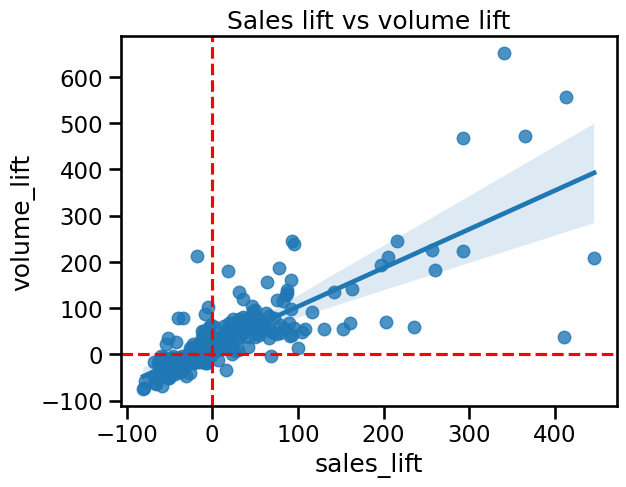

In [392]:
g=sns.regplot(data=agg_lift4.dropna(), x='sales_lift', y='volume_lift', x_ci=95)
g.axhline(y=0, color='red', linestyle='--', label=f"zero")
g.axvline(x=0, color='red', linestyle='--', label=f"zero")
g.set_title('Sales lift vs volume lift')

In [393]:
agg_lift4[(agg_lift4['volume_lift']<0) 
          & (agg_lift4['sales_lift']<0)].dropna().sort_values(by=['sales_lift', 'volume_lift'], ascending=True)

,terms,section,season,material,promo_count,volume_lift,sales_lift,price_lift,discount_actual
280,t-shirts,MAN,Autumn,Acrylic,2.0,-75.468583,-80.577567,-87.861756,0.208263
92,jeans,MAN,Spring,Polyester,1.0,-73.092105,-80.210853,-87.848983,0.264560
133,jeans,WOMAN,Winter,Acrylic,2.0,-57.794383,-78.893677,-88.076341,0.499917
221,sweaters,MAN,Spring,Satin,1.0,-16.976456,-67.941216,-80.638916,0.613859
306,t-shirts,MAN,Winter,Denim,1.0,-46.722812,-67.492985,-79.996520,0.389851
...,...,...,...,...,...,...,...,...,...
349,t-shirts,WOMAN,Winter,Wool,56.0,-14.854633,-6.740727,-40.780975,-0.095295
204,shoes,WOMAN,Winter,Viscose,5.0,-18.784195,-6.519987,-41.025641,-0.151008
242,sweaters,MAN,Winter,Wool Blend,35.0,-5.887763,-6.111040,-39.864857,0.002372
199,shoes,WOMAN,Winter,Acrylic,12.0,-0.112006,-2.565571,-39.839510,0.024563


In [394]:
agg_lift4[(agg_lift4['volume_lift']>0) 
          & (agg_lift4['sales_lift']>0)].dropna().sort_values(
              by=['sales_lift', 'volume_lift'], ascending=False).drop(columns=['price_lift']).head(10)

,terms,section,season,material,promo_count,volume_lift,sales_lift,discount_actual
233,sweaters,MAN,Summer,Wool,2.0,207.580478,445.806417,-0.774516
160,shoes,MAN,Summer,Polyester,4.0,556.338028,412.457106,0.219218
26,jackets,MAN,Summer,Satin,1.0,37.074830,410.430398,-2.723735
83,jeans,MAN,Autumn,Polyester,7.0,471.710933,364.930345,0.186774
340,t-shirts,WOMAN,Summer,Wool,4.0,651.007557,340.996364,0.412794
303,t-shirts,MAN,Summer,Wool Blend,4.0,222.662890,292.402052,-0.216136
96,jeans,MAN,Summer,Cotton,7.0,467.638484,292.299386,0.308892
230,sweaters,MAN,Summer,Polyester,4.0,181.767956,260.049549,-0.277823
292,t-shirts,MAN,Spring,Linen Blend,14.0,226.051958,256.522702,-0.093454
223,sweaters,MAN,Spring,Wool,1.0,58.935361,236.033017,-1.114275


### Frequency table Season x Material

In [395]:
agg_lift4.dropna().groupby(by=['season','material']).agg(
    promo_count=('sales_lift', 'count'),
    fail_rate_pct=('sales_lift', lambda x: (x<0).mean()*100)
).reset_index().sort_values(by='fail_rate_pct', ascending=False)

,season,material,promo_count,fail_rate_pct
14,Spring,Satin,5,100.000000
19,Summer,Acrylic,1,100.000000
33,Winter,Satin,2,100.000000
36,Winter,Wool,10,90.000000
13,Spring,Polyester,10,80.000000
7,Autumn,Wool,10,80.000000
18,Spring,Wool Blend,8,75.000000
22,Summer,Linen,10,70.000000
32,Winter,Polyester,10,70.000000
35,Winter,Viscose,9,66.666667


## What should we do?

### Bucket the discount

In [396]:
# Python Code to create Discount Buckets
agg_lift4['discount_bucket'] = pd.cut(agg_lift4['discount_actual']*100, 
                               bins=[-20, 0, 10, 20, 30, 40, 50, 60], 
                               labels=['No Discount', '0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50%+'])

# Analyze performance per bucket
bucket_performance = agg_lift4.groupby('discount_bucket').agg({
    'volume_lift': 'mean',
    'sales_lift': 'mean'
}).sort_values(by=['discount_bucket','volume_lift'])
print(bucket_performance)

                 volume_lift  sales_lift
discount_bucket                         
No Discount        44.278648   55.586188
0-10%              18.474758   11.756895
10-20%             25.570858    6.192476
20-30%             33.595260    1.419164
30-40%             36.409543  -10.612768
40-50%            101.345879   15.863838
50%+               44.609524  -34.960039


C:\Users\haiduong.nguyenle\AppData\Local\Temp\ipykernel_19684\3530501970.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_performance = agg_lift4.groupby('discount_bucket').agg({


In [397]:
agg_lift4[((agg_lift4['volume_lift']>90) )
          & ((agg_lift4['sales_lift']>14)  ) & (agg_lift4['discount_bucket']=='40-50%')
          ].dropna().sort_values(
              by=['sales_lift', 'volume_lift'], ascending=False).drop(columns=['price_lift']).head(10)

,terms,section,season,material,promo_count,volume_lift,sales_lift,discount_actual,discount_bucket
340,t-shirts,WOMAN,Summer,Wool,4.0,651.007557,340.996364,0.412794,40-50%
186,shoes,WOMAN,Spring,Viscose,17.0,239.307564,95.343924,0.424287,40-50%
85,jeans,MAN,Autumn,Viscose,4.0,244.109948,93.585070,0.437433,40-50%
68,jackets,WOMAN,Summer,Viscose,8.0,135.325685,31.666337,0.440493,40-50%


## Calculate "Efficiency Point"

In [398]:
# Efficiency Calculation
agg_lift4 = agg_lift4.dropna()
agg_lift4['efficiency_score'] = agg_lift4['volume_lift'] / agg_lift4['discount_actual']
best_discount = agg_lift4.loc[agg_lift4['efficiency_score'].idxmax(), 'discount_actual']
best_discount * 100

C:\Users\haiduong.nguyenle\AppData\Local\Temp\ipykernel_19684\568888982.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agg_lift4['efficiency_score'] = agg_lift4['volume_lift'] / agg_lift4['discount_actual']


np.float64(1.59622291167405)

In [399]:
agg_lift4.sort_values(by=['efficiency_score'], ascending=False)

,terms,section,season,material,promo_count,volume_lift,sales_lift,price_lift,discount_actual,discount_bucket,efficiency_score
175,shoes,WOMAN,Autumn,Satin,4.0,209.698630,204.755150,96.408010,0.015962,0-10%,13137.177057
142,shoes,MAN,Autumn,Denim,11.0,58.529946,55.434531,2.650182,0.019526,0-10%,2997.578331
154,shoes,MAN,Spring,Viscose,9.0,244.354336,216.257932,111.119890,0.081592,0-10%,2994.848569
4,jackets,MAN,Autumn,Satin,6.0,99.093199,91.458081,18.121590,0.038349,0-10%,2583.952326
213,sweaters,MAN,Autumn,Viscose,19.0,77.850361,72.408595,5.633414,0.030597,0-10%,2544.342145
...,...,...,...,...,...,...,...,...,...,...,...
229,sweaters,MAN,Summer,Linen Blend,12.0,133.859890,142.530773,54.603794,-0.037077,No Discount,-3610.296684
220,sweaters,MAN,Spring,Polyester,15.0,58.333333,60.581660,-5.187544,-0.014200,No Discount,-4107.993331
240,sweaters,MAN,Winter,Viscose,3.0,-42.563380,-43.105664,-64.133244,0.009441,0-10%,-4508.147582
81,jeans,MAN,Autumn,Cotton,11.0,192.196594,197.542818,86.459994,-0.018297,No Discount,-10504.459345


### Linear Volume and Discount

In [400]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare data: use discount_actual as predictor, volume_lift as target
X = agg_lift4[['discount_actual']].values
y = agg_lift4['volume_lift'].values

model = LinearRegression()
model.fit(X, y)

# Coefficient: Change in volume lift per unit change in discount
slope_volume = model.coef_[0]
intercept_volume = model.intercept_

print(f"Slope (coefficient): {slope_volume:.4f}")
print(f"Intercept: {intercept_volume:.2f}")
print(f"Equation: Volume_Lift = ({slope_volume:.4f} × Discount_) + {intercept_volume:.2f}")

Slope (coefficient): 52.1167
Intercept: 24.29
Equation: Volume_Lift = (52.1167 × Discount_) + 24.29


### Linear Volume and Discount

In [401]:
# Prepare data: use discount_actual as predictor, volume_lift as target
X = agg_lift4[['discount_actual']].values
y = agg_lift4['sales_lift'].values

model = LinearRegression()
model.fit(X, y)

# Coefficient: Change in volume lift per unit change in discount
slope_sales = model.coef_[0]
intercept_sales = model.intercept_

print(f"Slope (coefficient): {slope_sales:.4f}")
print(f"Intercept: {intercept_sales:.2f}")
print(f"Equation: Sales_Lift = ({slope_sales:.4f} × Discount_) + {intercept_sales:.2f}")

Slope (coefficient): -101.9589
Intercept: 26.70
Equation: Sales_Lift = (-101.9589 × Discount_) + 26.70


## Linear PLOT

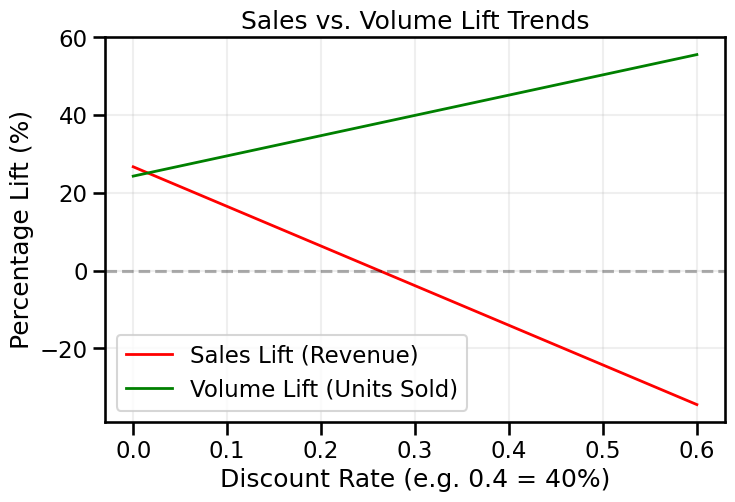

In [402]:
# 1. Setup the range for Discount (0% to 60%)
x = np.linspace(0, 0.6, 100)

# 2. Define your equations
y_sales = slope_sales * x + intercept_sales
y_volume = slope_volume * x + intercept_volume

# 3. Create the simple plot
plt.figure(figsize=(8, 5))

plt.plot(x, y_sales, label='Sales Lift (Revenue)', color='red', linewidth=2)
plt.plot(x, y_volume, label='Volume Lift (Units Sold)', color='green', linewidth=2)

# 4. Add a reference line at 0 (the break-even point)
plt.axhline(0, color='black', linestyle='--', alpha=0.3)

# 5. Labels and Legend
plt.title('Sales vs. Volume Lift Trends')
plt.xlabel('Discount Rate (e.g. 0.4 = 40%)')
plt.ylabel('Percentage Lift (%)')
plt.legend()
plt.grid(True, alpha=0.2)

plt.show()


## Prescriptive Discount Opti

In [403]:
print(agg_lift4.shape)

(264, 11)


In [404]:
agg_lift5 = df_uplift(agg_lift)
agg_lift5['discount_bucket'] = pd.cut(agg_lift5['discount_actual']*100,
                                      bins=[-20,0,10,20,30,40,50,60],
                                      labels=['No Discount', '0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50%+'])
agg_lift5

,Product Position,terms,section,season,material,promo_count,volume_lift,sales_lift,price_lift,discount_actual,discount_bucket
0,Aisle,jackets,MAN,Autumn,Acrylic,10.0,-22.688916,-32.642498,-58.937085,0.128747,10-20%
1,Aisle,jackets,MAN,Autumn,Cotton,43.0,22.722196,19.330447,-21.167233,0.027638,0-10%
2,Aisle,jackets,MAN,Autumn,Denim,18.0,20.468758,12.329659,-31.903990,0.067562,0-10%
3,Aisle,jackets,MAN,Autumn,Polyester,42.0,-13.031204,-14.102615,-45.989744,0.012319,0-10%
4,Aisle,jackets,MAN,Autumn,Satin,1.0,-58.632640,-47.005180,-67.969055,-0.281078,NaN
...,...,...,...,...,...,...,...,...,...,...,...
910,Front of Store,t-shirts,WOMAN,Winter,Polyester,5.0,-27.004849,-13.917430,-47.868484,-0.179292,No Discount
911,Front of Store,t-shirts,WOMAN,Winter,Satin,NaN,NaN,NaN,NaN,NaN,NaN
912,Front of Store,t-shirts,WOMAN,Winter,Viscose,NaN,NaN,NaN,NaN,NaN,NaN
913,Front of Store,t-shirts,WOMAN,Winter,Wool,15.0,3.326003,12.216418,-28.114828,-0.086042,No Discount


## Positive discount per segment groups

In [405]:
agg_lift5[(agg_lift5['terms']=='jackets') & (agg_lift5['section']=='MAN') & (agg_lift5['season']=='Autumn')
          & (agg_lift5['material']=='Polyester') ]

,Product Position,terms,section,season,material,promo_count,volume_lift,sales_lift,price_lift,discount_actual,discount_bucket
3,Aisle,jackets,MAN,Autumn,Polyester,42.0,-13.031204,-14.102615,-45.989744,0.012319,0-10%
314,End-cap,jackets,MAN,Autumn,Polyester,37.0,4.811417,-6.057136,-42.835404,0.103696,10-20%
621,Front of Store,jackets,MAN,Autumn,Polyester,42.0,91.954567,96.302999,26.334791,-0.022653,No Discount


In [406]:
agg_lift4

,terms,section,season,material,promo_count,volume_lift,sales_lift,price_lift,discount_actual,discount_bucket,efficiency_score
0,jackets,MAN,Autumn,Acrylic,33.0,0.502964,-16.014116,-47.902476,0.164344,10-20%,3.060432
1,jackets,MAN,Autumn,Cotton,104.0,16.837872,5.395624,-33.821497,0.097933,0-10%,171.933102
2,jackets,MAN,Autumn,Denim,42.0,-4.249405,-12.792725,-46.513706,0.089225,0-10%,-47.625873
3,jackets,MAN,Autumn,Polyester,121.0,14.744598,10.613883,-30.888009,0.035999,0-10%,409.581151
4,jackets,MAN,Autumn,Satin,6.0,99.093199,91.458081,18.121590,0.038349,0-10%,2583.952326
...,...,...,...,...,...,...,...,...,...,...,...
344,t-shirts,WOMAN,Winter,Denim,5.0,187.841281,78.383473,0.019622,0.380271,30-40%,493.966359
345,t-shirts,WOMAN,Winter,Polyester,31.0,37.453494,14.826055,-30.945239,0.164619,10-20%,227.516410
348,t-shirts,WOMAN,Winter,Viscose,3.0,-45.778792,-49.519337,-69.671987,0.068987,0-10%,-663.588193
349,t-shirts,WOMAN,Winter,Wool,56.0,-14.854633,-6.740727,-40.780975,-0.095295,No Discount,155.880918


In [407]:
agg_lift4.sort_values('sales_lift', ascending=False)

,terms,section,season,material,promo_count,volume_lift,sales_lift,price_lift,discount_actual,discount_bucket,efficiency_score
160,shoes,MAN,Summer,Polyester,4.0,556.338028,412.457106,211.181818,0.219218,20-30%,2537.833367
83,jeans,MAN,Autumn,Polyester,7.0,471.710933,364.930345,184.833708,0.186774,10-20%,2525.574207
340,t-shirts,WOMAN,Summer,Wool,4.0,651.007557,340.996364,134.383869,0.412794,40-50%,1577.077233
96,jeans,MAN,Summer,Cotton,7.0,467.638484,292.299386,135.631810,0.308892,30-40%,1513.921326
292,t-shirts,MAN,Spring,Linen Blend,14.0,226.051958,256.522702,120.555453,-0.093454,No Discount,-2418.867185
...,...,...,...,...,...,...,...,...,...,...,...
70,jackets,WOMAN,Summer,Wool Blend,6.0,-51.738371,-66.889293,-80.243579,0.313933,30-40%,-164.807011
306,t-shirts,MAN,Winter,Denim,1.0,-46.722812,-67.492985,-79.996520,0.389851,30-40%,-119.847826
133,jeans,WOMAN,Winter,Acrylic,2.0,-57.794383,-78.893677,-88.076341,0.499917,40-50%,-115.608021
92,jeans,MAN,Spring,Polyester,1.0,-73.092105,-80.210853,-87.848983,0.264560,20-30%,-276.278184


## Maintain discount when sales lift effective
if sale lift > 0

In [474]:
agg_lift4_pos = agg_lift4[(agg_lift4.sales_lift > 0)]
agg_lift4_pos['recommendation'] = 'Maintain'
agg_lift4_pos['discount_rec'] = 'Maintain discount actual'
result_pos = agg_lift4_pos
result_pos

C:\Users\haiduong.nguyenle\AppData\Local\Temp\ipykernel_19684\1239095763.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agg_lift4_pos['recommendation'] = 'Maintain'
C:\Users\haiduong.nguyenle\AppData\Local\Temp\ipykernel_19684\1239095763.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agg_lift4_pos['discount_rec'] = 'Maintain discount actual'


,terms,section,season,material,promo_count,volume_lift,sales_lift,price_lift,discount_actual,discount_bucket,efficiency_score,recommendation,discount_rec
1,jackets,MAN,Autumn,Cotton,104.0,16.837872,5.395624,-33.821497,0.097933,0-10%,171.933102,Maintain,Maintain discount actual
3,jackets,MAN,Autumn,Polyester,121.0,14.744598,10.613883,-30.888009,0.035999,0-10%,409.581151,Maintain,Maintain discount actual
4,jackets,MAN,Autumn,Satin,6.0,99.093199,91.458081,18.121590,0.038349,0-10%,2583.952326,Maintain,Maintain discount actual
6,jackets,MAN,Autumn,Viscose,51.0,55.429388,39.372929,-14.029372,0.103304,10-20%,536.566387,Maintain,Maintain discount actual
8,jackets,MAN,Autumn,Wool Blend,145.0,23.415662,12.542637,-30.722053,0.088101,0-10%,265.782476,Maintain,Maintain discount actual
...,...,...,...,...,...,...,...,...,...,...,...,...,...
340,t-shirts,WOMAN,Summer,Wool,4.0,651.007557,340.996364,134.383869,0.412794,40-50%,1577.077233,Maintain,Maintain discount actual
342,t-shirts,WOMAN,Winter,Acrylic,14.0,40.410642,13.678401,-32.950927,0.190386,10-20%,212.256215,Maintain,Maintain discount actual
344,t-shirts,WOMAN,Winter,Denim,5.0,187.841281,78.383473,0.019622,0.380271,30-40%,493.966359,Maintain,Maintain discount actual
345,t-shirts,WOMAN,Winter,Polyester,31.0,37.453494,14.826055,-30.945239,0.164619,10-20%,227.516410,Maintain,Maintain discount actual


## Suggest optimize discount
when sale lift < 0

In [409]:
agg_lift4_neg = agg_lift4[(agg_lift4.sales_lift <= 0)]
print(agg_lift4_neg.shape)

(148, 11)


In [410]:
agg_lift4_neg[(agg_lift4_neg['terms']=='shoes') & (agg_lift4_neg['section']=='WOMAN')
              & (agg_lift4_neg['season']=='Summer')  & (agg_lift4_neg['material']=='Denim')
              ]

,terms,section,season,material,promo_count,volume_lift,sales_lift,price_lift,discount_actual,discount_bucket,efficiency_score
191,shoes,WOMAN,Summer,Denim,1.0,102.006689,-4.959002,-52.951559,0.529516,50%+,192.641521


In [411]:
agg_lift5[(agg_lift5['terms']=='shoes') & (agg_lift5['section']=='WOMAN')
              & (agg_lift5['season']=='Summer')  & (agg_lift5['material']=='Denim')
              ]

,Product Position,terms,section,season,material,promo_count,volume_lift,sales_lift,price_lift,discount_actual,discount_bucket
169,Aisle,shoes,WOMAN,Summer,Denim,1.0,NaN,NaN,NaN,NaN,NaN
479,End-cap,shoes,WOMAN,Summer,Denim,NaN,NaN,NaN,NaN,NaN,NaN


### For negative sales lift, look at the placement

In [412]:
agg_lift4_neg_group = agg_lift4_neg[['terms','season','section','material']]
agg_lift5_neg = agg_lift5.merge(right=agg_lift4_neg_group, on=['terms','season','section','material'], how='right',
                                suffixes=('','_'))
agg_lift5_neg = agg_lift5_neg[agg_lift5.columns].sort_values(by=['terms','season','section','material'])
agg_lift5_neg

,Product Position,terms,section,season,material,promo_count,volume_lift,sales_lift,price_lift,discount_actual,discount_bucket
0,Aisle,jackets,MAN,Autumn,Acrylic,10.0,-22.688916,-32.642498,-58.937085,0.128747,10-20%
1,End-cap,jackets,MAN,Autumn,Acrylic,13.0,6.720888,-13.690095,-46.957614,0.191256,10-20%
2,Front of Store,jackets,MAN,Autumn,Acrylic,10.0,28.498007,9.133414,-28.915022,0.150700,10-20%
3,Aisle,jackets,MAN,Autumn,Denim,18.0,20.468758,12.329659,-31.903990,0.067562,0-10%
4,End-cap,jackets,MAN,Autumn,Denim,12.0,-24.791335,-32.862847,-60.523258,0.107322,10-20%
...,...,...,...,...,...,...,...,...,...,...,...
422,End-cap,t-shirts,WOMAN,Winter,Viscose,1.0,-71.505476,-76.618647,-86.522104,0.179444,10-20%
423,Front of Store,t-shirts,WOMAN,Winter,Viscose,NaN,NaN,NaN,NaN,NaN,NaN
424,Aisle,t-shirts,WOMAN,Winter,Wool,20.0,-33.747196,-17.438818,-47.231100,-0.246154,NaN
425,End-cap,t-shirts,WOMAN,Winter,Wool,21.0,-0.556146,-5.306164,-41.209602,0.047766,0-10%


In [413]:
agg_lift5_neg.groupby(['terms','season','section','material']).agg(count=('material','count')).reset_index().shape

(148, 5)

In [414]:
print(agg_lift5_neg['Product Position'].isna().sum())

0


## Identify placement position and discount of that placement for recommendation

In [415]:
placement_effect = agg_lift5_neg.pivot_table(
    values='sales_lift',
    columns='Product Position',
    index=['terms','season','section','material']
).reset_index()
placement_effect['max_lift'] = placement_effect[['Aisle', 'End-cap', 'Front of Store']].max(axis=1)
print(f'placement effect shape: {placement_effect.shape}')


placement effect shape: (147, 8)


In [416]:
placement_effect['check'] = 1
test = agg_lift5_neg.merge(placement_effect,on=['terms','season','section','material'], how='left')
test[(test.check !=1)]

,Product Position,terms,section,season,material,promo_count,volume_lift,sales_lift,price_lift,discount_actual,discount_bucket,Aisle,End-cap,Front of Store,max_lift,check
215,Aisle,shoes,WOMAN,Summer,Denim,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
216,End-cap,shoes,WOMAN,Summer,Denim,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [417]:
# Find the best product placement
placement_effect = agg_lift5_neg.pivot_table(
    values='sales_lift',
    columns='Product Position',
    index=['terms','season','section','material']
).reset_index()
placement_effect['max_lift'] = placement_effect[['Aisle', 'End-cap', 'Front of Store']].max(axis=1)

# 3. Get the name of the column that had the highest value
cols = ['Aisle', 'End-cap', 'Front of Store']
placement_effect['best_position'] = placement_effect[cols].idxmax(axis=1)
print(f'placement effect shape: {placement_effect.shape}')

best_place = placement_effect[(placement_effect['max_lift']>0)]
best_place



placement effect shape: (147, 9)


Product Position,terms,season,section,material,Aisle,End-cap,Front of Store,max_lift,best_position
0,jackets,Autumn,MAN,Acrylic,-32.642498,-13.690095,9.133414,9.133414,Front of Store
1,jackets,Autumn,MAN,Denim,12.329659,-32.862847,-13.924630,12.329659,Aisle
3,jackets,Autumn,WOMAN,Denim,-52.699661,5.249409,61.707298,61.707298,Front of Store
4,jackets,Autumn,WOMAN,Polyester,-1.252015,10.875139,-17.574112,10.875139,End-cap
5,jackets,Autumn,WOMAN,Satin,-65.468576,-33.128437,9.380563,9.380563,Front of Store
...,...,...,...,...,...,...,...,...,...
142,t-shirts,Winter,MAN,Wool,-12.615791,4.486553,-31.693964,4.486553,End-cap
143,t-shirts,Winter,MAN,Wool Blend,-5.296981,12.125655,-15.959706,12.125655,End-cap
144,t-shirts,Winter,WOMAN,Cotton,-39.004297,70.798668,-62.170229,70.798668,End-cap
145,t-shirts,Winter,WOMAN,Viscose,72.193605,-76.618647,NaN,72.193605,Aisle


In [418]:
agg_lift5_neg.columns

Index(['Product Position', 'terms', 'section', 'season', 'material',
       'promo_count', 'volume_lift', 'sales_lift', 'price_lift',
       'discount_actual', 'discount_bucket'],
      dtype='object')

In [419]:
agg_lift4_neg.shape

(148, 11)

In [471]:
best_place_enrich = agg_lift4_neg.merge(right=best_place, left_on=['terms','season','section','material'],
                                          right_on=['terms','season','section','material'], how='left', suffixes=('','_place'))
best_place_enrich = best_place_enrich.dropna()[[ 'terms', 'section', 'season', 'material',
       'promo_count', 'volume_lift', 'sales_lift', 'price_lift',
       'discount_actual', 'discount_bucket','best_position', 'max_lift']]
# take the discount in best_position
best_place_enrich['discount_rec'] = best_place_enrich['discount_actual'] 
best_place_enrich

,terms,section,season,material,promo_count,volume_lift,sales_lift,price_lift,discount_actual,discount_bucket,best_position,max_lift,discount_rec
0,jackets,MAN,Autumn,Acrylic,33.0,0.502964,-16.014116,-47.902476,0.164344,10-20%,Front of Store,9.133414,0.164344
1,jackets,MAN,Autumn,Denim,42.0,-4.249405,-12.792725,-46.513706,0.089225,0-10%,Aisle,12.329659,0.089225
4,jackets,MAN,Spring,Linen Blend,25.0,-15.963871,-28.465139,-57.063567,0.148761,10-20%,Aisle,0.369095,0.148761
6,jackets,MAN,Spring,Viscose,18.0,-5.791817,-13.611795,-44.423906,0.083007,0-10%,Aisle,40.051876,0.083007
7,jackets,MAN,Spring,Wool Blend,17.0,32.836382,-3.540281,-39.515007,0.273846,20-30%,Front of Store,158.364623,0.273846
...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,t-shirts,WOMAN,Spring,Polyester,18.0,4.352039,-11.661277,-44.267462,0.153455,10-20%,Front of Store,8.430116,0.153455
140,t-shirts,WOMAN,Spring,Viscose,11.0,4.611878,-17.643849,-48.807313,0.212746,20-30%,Front of Store,527.918698,0.212746
141,t-shirts,WOMAN,Spring,Wool Blend,4.0,-10.538189,-12.377242,-44.425223,0.020557,0-10%,Aisle,103.478865,0.020557
145,t-shirts,WOMAN,Winter,Cotton,11.0,-12.277965,-40.661647,-65.631502,0.323564,30-40%,End-cap,70.798668,0.323564


In [421]:
placement_effect.shape

(147, 9)

In [472]:
best_place_enrich['recommendation'] = 'Product Replacement at: ' + best_place_enrich['best_position']
best_place_enrich.drop(columns = 'best_position')
print(best_place_enrich.shape)
best_place_enrich



(71, 14)


,terms,section,season,material,promo_count,volume_lift,sales_lift,price_lift,discount_actual,discount_bucket,best_position,max_lift,discount_rec,recommendation
0,jackets,MAN,Autumn,Acrylic,33.0,0.502964,-16.014116,-47.902476,0.164344,10-20%,Front of Store,9.133414,0.164344,Product Replacement at: Front of Store
1,jackets,MAN,Autumn,Denim,42.0,-4.249405,-12.792725,-46.513706,0.089225,0-10%,Aisle,12.329659,0.089225,Product Replacement at: Aisle
4,jackets,MAN,Spring,Linen Blend,25.0,-15.963871,-28.465139,-57.063567,0.148761,10-20%,Aisle,0.369095,0.148761,Product Replacement at: Aisle
6,jackets,MAN,Spring,Viscose,18.0,-5.791817,-13.611795,-44.423906,0.083007,0-10%,Aisle,40.051876,0.083007,Product Replacement at: Aisle
7,jackets,MAN,Spring,Wool Blend,17.0,32.836382,-3.540281,-39.515007,0.273846,20-30%,Front of Store,158.364623,0.273846,Product Replacement at: Front of Store
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,t-shirts,WOMAN,Spring,Polyester,18.0,4.352039,-11.661277,-44.267462,0.153455,10-20%,Front of Store,8.430116,0.153455,Product Replacement at: Front of Store
140,t-shirts,WOMAN,Spring,Viscose,11.0,4.611878,-17.643849,-48.807313,0.212746,20-30%,Front of Store,527.918698,0.212746,Product Replacement at: Front of Store
141,t-shirts,WOMAN,Spring,Wool Blend,4.0,-10.538189,-12.377242,-44.425223,0.020557,0-10%,Aisle,103.478865,0.020557,Product Replacement at: Aisle
145,t-shirts,WOMAN,Winter,Cotton,11.0,-12.277965,-40.661647,-65.631502,0.323564,30-40%,End-cap,70.798668,0.323564,Product Replacement at: End-cap


## When No effect of placement

In [473]:
# These product segments are having no 
no_placement_effect=placement_effect[(placement_effect.max_lift<=0)][['terms', 'season','material','section']]
print(f'how many product segments without placement effect: {no_placement_effect.shape}')
agg_lift4_neg2 = agg_lift4_neg.merge(right=no_placement_effect, on=['terms', 'season','material','section'], how='right').dropna()
print(agg_lift4_neg2.shape)
agg_lift4_neg2 = agg_lift4_neg2[['terms', 'section', 'season', 'material', 'promo_count', 'volume_lift',
       'sales_lift', 'price_lift', 'discount_actual', 'discount_bucket']]
agg_lift4_neg2['recommendation'] = "TBC"
agg_lift4_neg2['discount_rec'] = "TBC"
agg_lift4_neg2 = agg_lift4_neg2.reindex(sorted(agg_lift4_neg2.columns), axis=1)
agg_lift4_neg2

how many product segments without placement effect: (46, 4)
(46, 11)


,discount_actual,discount_bucket,discount_rec,material,price_lift,promo_count,recommendation,sales_lift,season,section,terms,volume_lift
0,0.061307,0-10%,TBC,Wool,-52.251501,115.0,TBC,-22.477437,Autumn,MAN,jackets,-17.414359
1,0.224003,20-30%,TBC,Cotton,-49.921156,114.0,TBC,-17.595236,Spring,MAN,jackets,6.192113
2,0.139537,10-20%,TBC,Linen,-42.319918,191.0,TBC,-5.387257,Spring,WOMAN,jackets,9.955647
3,0.240862,20-30%,TBC,Polyester,-52.143120,71.0,TBC,-21.753464,Spring,WOMAN,jackets,3.072903
4,0.271714,20-30%,TBC,Wool,-76.710809,4.0,TBC,-59.750661,Summer,MAN,jackets,-44.734127
5,0.464266,40-50%,TBC,Acrylic,-72.592148,3.0,TBC,-53.246259,Summer,WOMAN,jackets,-12.729587
6,0.185617,10-20%,TBC,Linen Blend,-48.880040,49.0,TBC,-17.312572,Summer,WOMAN,jackets,1.533866
7,0.313933,30-40%,TBC,Wool Blend,-80.243579,6.0,TBC,-66.889293,Summer,WOMAN,jackets,-51.738371
8,0.330380,30-40%,TBC,Acrylic,-63.012279,30.0,TBC,-35.260117,Winter,MAN,jackets,-3.318422
9,0.239791,20-30%,TBC,Satin,-70.157466,2.0,TBC,-52.681147,Winter,WOMAN,jackets,-37.755503


# Merge result

In [475]:

# remove col
result_pos = result_pos[result_pos.columns.difference(['efficiency_score'])]
best_place_enrich = best_place_enrich[best_place_enrich.columns.difference(['max_lift','best_position'])]

result_pos = result_pos.reindex(sorted(result_pos.columns), axis=1)
best_place_enrich = best_place_enrich.reindex(sorted(best_place_enrich.columns), axis=1)



## original df by terms section season material

In [476]:

agg_lift_for_merge = df.pivot_table(
    index=[ 'terms', 'section', 'season', 'material'], 
    columns='Promotion', 
    values=['Sales Volume', 'sales', 'price'], 
    aggfunc={'Sales Volume': 'sum', 'sales': 'sum', 'price': 'sum', 'Promotion': 'count'}
).reset_index()
agg_lift_for_merge.columns = [ 'terms', 'section', 'season', 'material', 'promotion_no', 'promo_count',
                          'volume_no', 'volume_yes','price_no', 'price_yes', 'sales_no', 'sales_yes'
                          ]

agg_lift_for_merge = agg_lift_for_merge.drop(columns='promotion_no')
agg_lift_for_merge.head()

,terms,section,season,material,promo_count,volume_no,volume_yes,price_no,price_yes,sales_no,sales_yes
0,jackets,MAN,Autumn,Acrylic,33.0,41156.0,41363.0,2219.76,1156.44,1681621.35,1412324.55
1,jackets,MAN,Autumn,Cotton,104.0,109907.0,128413.0,6309.36,4175.44,4690526.69,4943609.89
2,jackets,MAN,Autumn,Denim,42.0,55043.0,52704.0,2808.57,1502.20,2106557.96,1837071.80
3,jackets,MAN,Autumn,Polyester,121.0,132184.0,151674.0,6809.73,4706.34,5172837.50,5721876.44
4,jackets,MAN,Autumn,Satin,6.0,3970.0,7904.0,153.96,181.86,122244.89,234047.72


In [477]:
result_merged = pd.concat([result_pos, best_place_enrich, agg_lift4_neg2], 
                          axis=0, ignore_index=True)[['terms', 'section', 'season', 'material', 'recommendation', 'discount_rec']]


result_merged_rejoined = result_merged.merge(right=agg_lift_for_merge, on=['terms', 'section', 'season', 'material'], how='left')
result_merged_rejoined

,terms,section,season,material,recommendation,discount_rec,promo_count,volume_no,volume_yes,price_no,price_yes,sales_no,sales_yes
0,jackets,MAN,Autumn,Cotton,Maintain,Maintain discount actual,104.0,109907.0,128413.0,6309.36,4175.44,4690526.69,4943609.89
1,jackets,MAN,Autumn,Polyester,Maintain,Maintain discount actual,121.0,132184.0,151674.0,6809.73,4706.34,5172837.50,5721876.44
2,jackets,MAN,Autumn,Satin,Maintain,Maintain discount actual,6.0,3970.0,7904.0,153.96,181.86,122244.89,234047.72
3,jackets,MAN,Autumn,Viscose,Maintain,Maintain discount actual,51.0,41303.0,64197.0,2108.79,1812.94,1589449.55,2215262.40
4,jackets,MAN,Autumn,Wool Blend,Maintain,Maintain discount actual,145.0,148106.0,182786.0,7925.87,5490.88,5978758.21,6728652.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...
228,t-shirts,MAN,Summer,Cotton,TBC,TBC,14.0,29416.0,19962.0,1619.28,611.71,1365102.65,824932.12
229,t-shirts,MAN,Summer,Linen Blend,TBC,TBC,5.0,9930.0,7302.0,459.66,174.92,398407.26,245831.07
230,t-shirts,WOMAN,Summer,Viscose,TBC,TBC,2.0,5055.0,3351.0,250.88,74.94,246842.56,125385.85
231,t-shirts,MAN,Winter,Denim,TBC,TBC,1.0,2731.0,1455.0,114.93,22.99,102902.25,33450.45


In [478]:
result_merged_rejoined.columns

Index(['terms', 'section', 'season', 'material', 'recommendation',
       'discount_rec', 'promo_count', 'volume_no', 'volume_yes', 'price_no',
       'price_yes', 'sales_no', 'sales_yes'],
      dtype='object')

# Export

In [479]:
final_zara_product = result_merged_rejoined[['terms', 'section', 'season', 'material',  'sales_no', 'sales_yes', 'volume_no', 'volume_yes', 'recommendation',
       'discount_rec' ]]
final_zara_product.to_csv('final_zara_product_placement.csv', index=False)
